In [ ]:
import numpy as np 
import pandas as pd


In [3]:
data = pd.read_csv('digit.csv')


In [4]:
data.shape

(42000, 785)

In [5]:
data.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18508,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import matplotlib.pyplot as plt

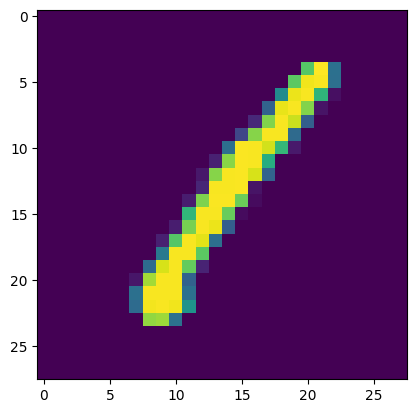

In [8]:
plt.imshow(data.iloc[0,1:].values.reshape(28,28))

In [11]:
X = data.iloc[:,1:]
y = data.iloc[:,0]

In [13]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
y.head()

0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((33600, 784), (8400, 784), (33600,), (8400,))

In [77]:
from sklearn.neighbors import KNeighborsClassifier

In [78]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [79]:
y_pred = knn.predict(X_test)

In [80]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [82]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None) #If we set 

In [84]:
X_train_without_pca = pca.fit_transform(X_train)

In [85]:
X_test_without_pca = pca.fit_transform(X_test)

In [86]:
X_train_without_pca.shape, X_test_without_pca.shape, y_train.shape, y_test.shape

((33600, 784), (8400, 784), (33600,), (8400,))

In [87]:
pca = PCA(n_components=100)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [88]:
X_train_trf.shape, X_test_trf.shape, y_train.shape, y_test.shape

((33600, 100), (8400, 100), (33600,), (8400,))

In [93]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [94]:
y_pred = knn.predict(X_test_trf)

In [95]:
accuracy_score(y_test,y_pred)

0.9544047619047619

In [104]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],y=X_train_trf[:,1],color=y_train_trf)
fig.show(renderer="browser")

In [107]:
pca.components_.shape
#Eigen Vectors

(100, 784)

In [ ]:
pca.explained_variance_
#Eigen Values

array([40.67111198, 29.17023401, 26.74459621, 20.85344792, 18.14891878,
       15.8529825 , 13.87108101, 12.48058967, 11.02794236, 10.09582533,
        9.63317821,  8.62785945,  8.06303131,  7.89511749,  7.44167929,
        7.17032873,  6.73266373,  6.62744023,  6.41499161,  6.25808269,
        5.90495742,  5.76521585,  5.52084601,  5.32003847,  5.18309925,
        4.93439597,  4.90652171,  4.71800493,  4.49824444,  4.43140305,
        4.32604521,  4.23491831,  4.10335015,  4.0673118 ,  4.02362178,
        3.84130473,  3.81886146,  3.71316498,  3.60918108,  3.47303214,
        3.42842989,  3.38841159,  3.29157511,  3.22927379,  3.21745142,
        3.15810372,  3.12620905,  3.10412385,  3.05892795,  3.03728188,
        2.96540461,  2.94033669,  2.86828564,  2.82617865,  2.80038441,
        2.77411221,  2.71978838,  2.69394232,  2.64724369,  2.63065837,
        2.56498699,  2.53651735,  2.48789582,  2.44610051,  2.42066567,
        2.37577156,  2.35505085,  2.33408709,  2.29804042,  2.25

In [109]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

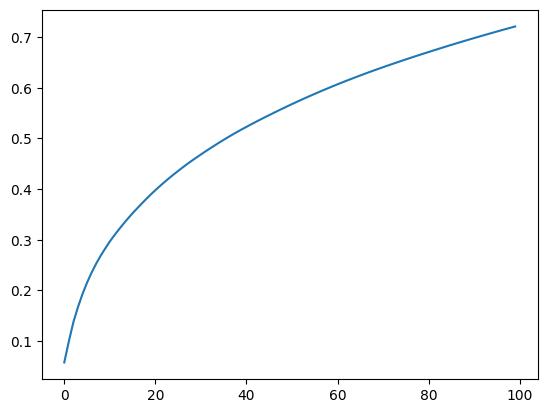

In [110]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))